# Titanic Exploratory Data Analysis

## Objective
Explore the Titanic dataset to understand passenger characteristics and survival patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Data

In [3]:
df = pd.read_csv("D:/App Data/Data for python/titanic/train.csv")


# Data Overview

In [4]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


# Information

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


# Rows x column

In [6]:
print(df.shape)

(891, 12)


# Description

In [7]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


# Null values

In [8]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Duplicate values

In [9]:
print(df.duplicated().sum())

0


# Survivers

In [10]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


# Male and Females

In [11]:
print(df["Sex"].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


# No of Pclass

In [12]:
print(df["Pclass"].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


# Filling missing age...

In [13]:
df["Age"] = df["Age"].fillna(df["Age"].median())

# Filling missing embarked values...

In [14]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Dropping cabin columns...

In [15]:
df.drop(columns=["Cabin"], inplace=True)

# Null values

In [16]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Information

In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB
None


## Survival Count

### Observation
- More passengers did not survive than survived.
- The dataset contains a higher number of non-survivors.
- Survival is the target variable used for further analysis.

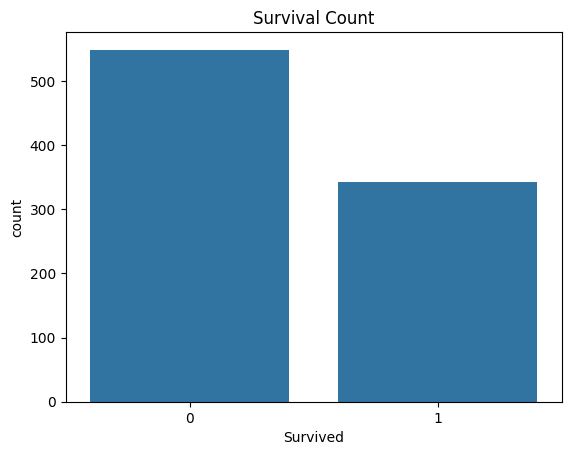

In [18]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

## Gender Distribution

### Observation
- Male passengers were more numerous than female passengers.
- The dataset is not evenly distributed by gender.
- Gender may have influenced survival rates.

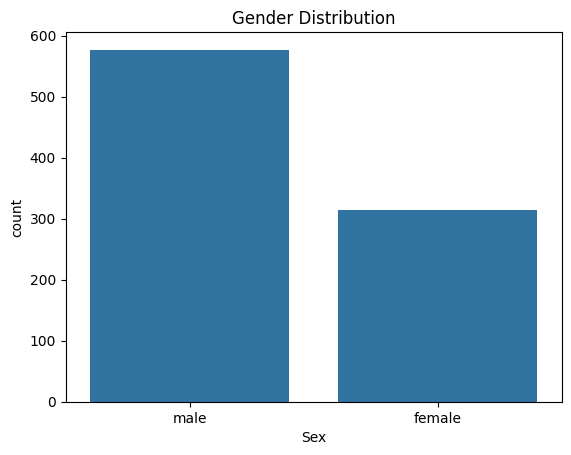

In [19]:
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

## Passenger Class Distribution

### Observation
- Most passengers traveled in Third Class.
- First Class had the fewest passengers.
- Passenger class may have affected survival probability.

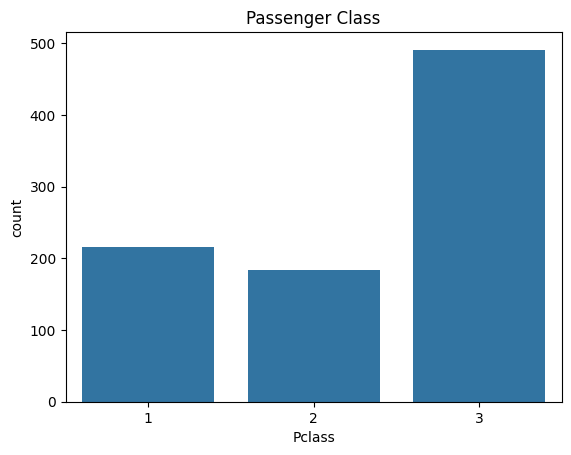

In [20]:
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class")
plt.show()

## Age Distribution

### Observation
- Most passengers were between 20 and 40 years old.
- The age distribution is slightly right-skewed.
- Very young children and elderly passengers made up a smaller portion of the dataset.

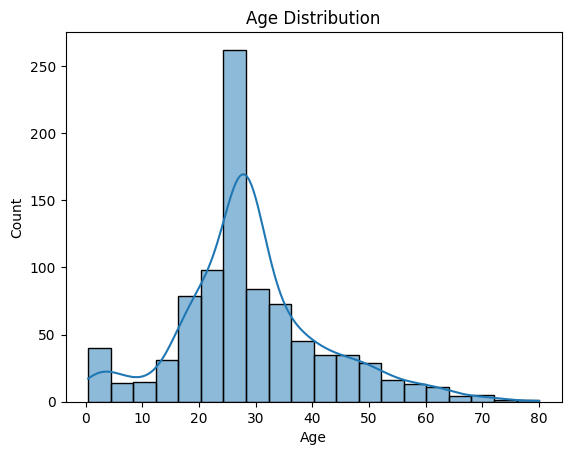

In [21]:
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

## Fare Distribution

### Observation
- Most passengers paid relatively low fares.
- The distribution is highly right-skewed.
- A small number of passengers paid significantly higher fares.

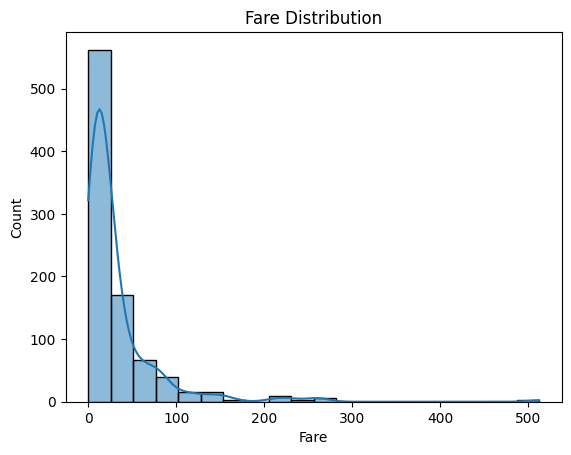

In [22]:
sns.histplot(df["Fare"], bins=20, kde=True)
plt.title("Fare Distribution")
plt.show()

## Age Boxplot

### Observation
- The majority of passengers fall within the middle age range.
- A few passengers appear as outliers.
- The boxplot helps visualize the spread of passenger ages.

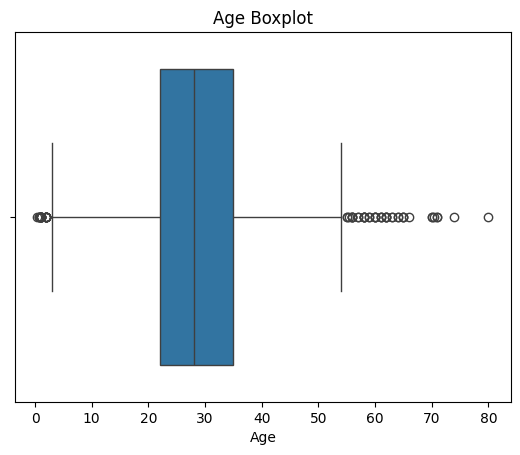

In [23]:
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

## Fare Boxplot

### Observation
- Several high-fare outliers are present.
- Most passengers paid fares within a relatively small range.
- Extreme fare values may represent luxury accommodations.

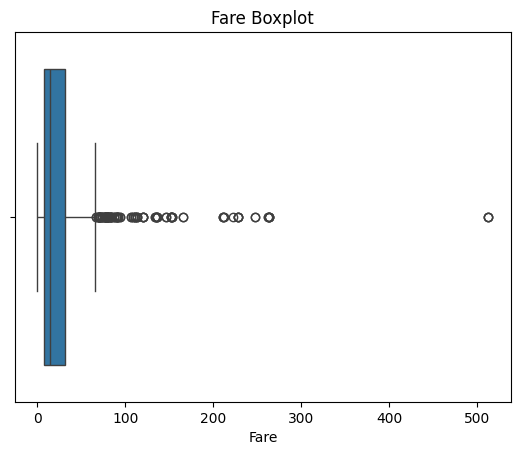

In [24]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

## Survival by Gender

### Observation
- Female passengers had a higher survival rate than male passengers.
- Male passengers experienced a greater number of fatalities.
- Gender appears to have been an important factor in survival.

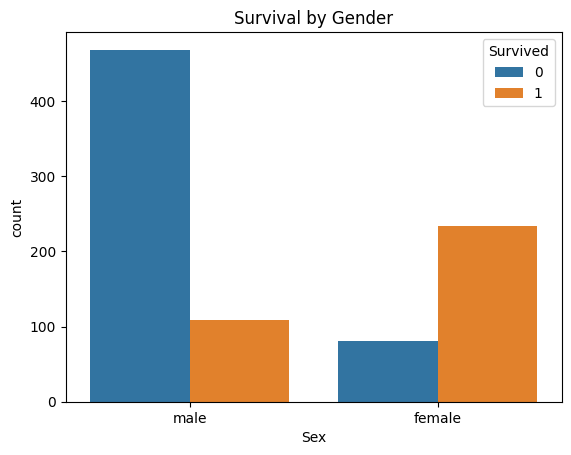

In [25]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

## Survival by Passenger Class

### Observation
- First Class passengers had a higher survival rate.
- Third Class passengers experienced the lowest survival rate.
- Passenger class appears to be associated with survival outcomes.

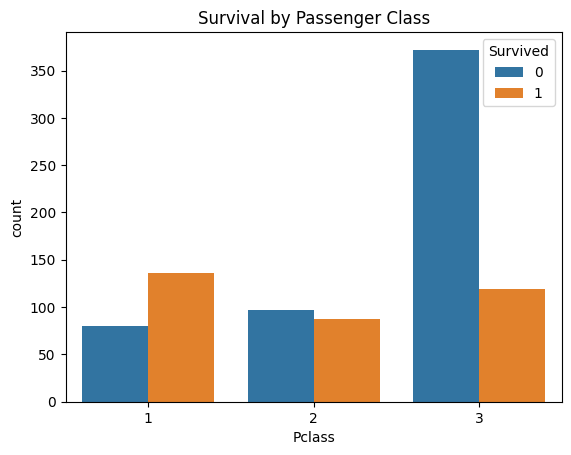

In [26]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

## Age vs Fare

### Observation
- No strong linear relationship is visible between age and fare.
- Higher fares are concentrated among a small group of passengers.
- Passenger age alone does not explain ticket price.

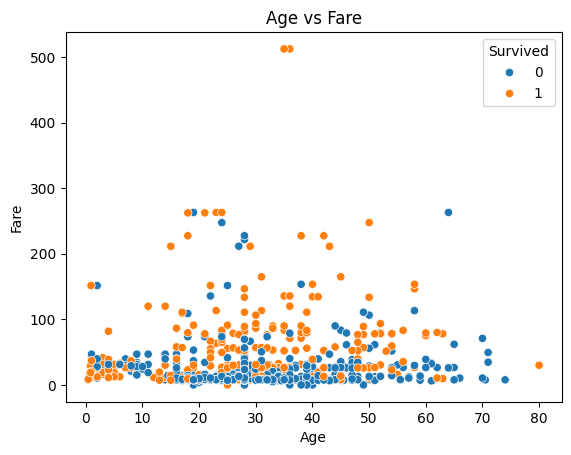

In [27]:
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df)
plt.title("Age vs Fare")
plt.show()

## Correlation Heatmap

### Observation
- Passenger class and fare show a noticeable relationship.
- Survival has some correlation with passenger class and fare.
- Most numerical features show weak to moderate correlations.

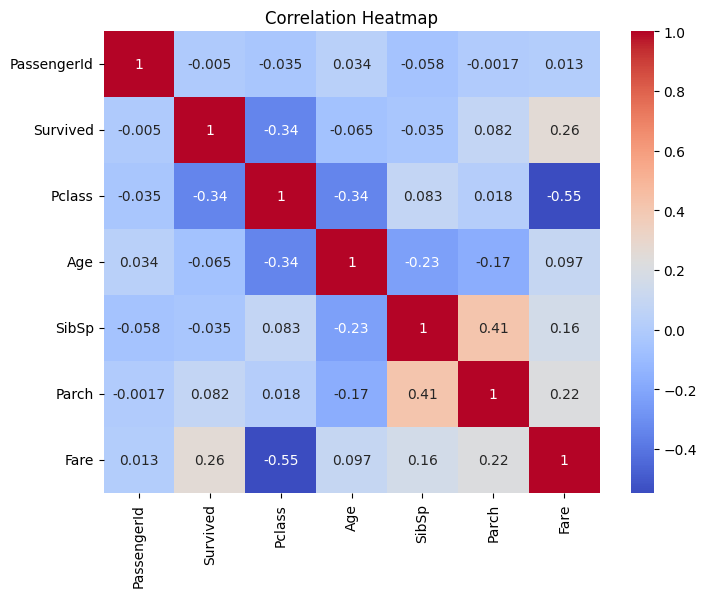

In [28]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## Pair Plot

### Observation
- The pair plot helps visualize relationships among numerical variables.
- Survival groups show some separation based on fare and passenger class.
- It provides an overview of distributions and feature interactions.

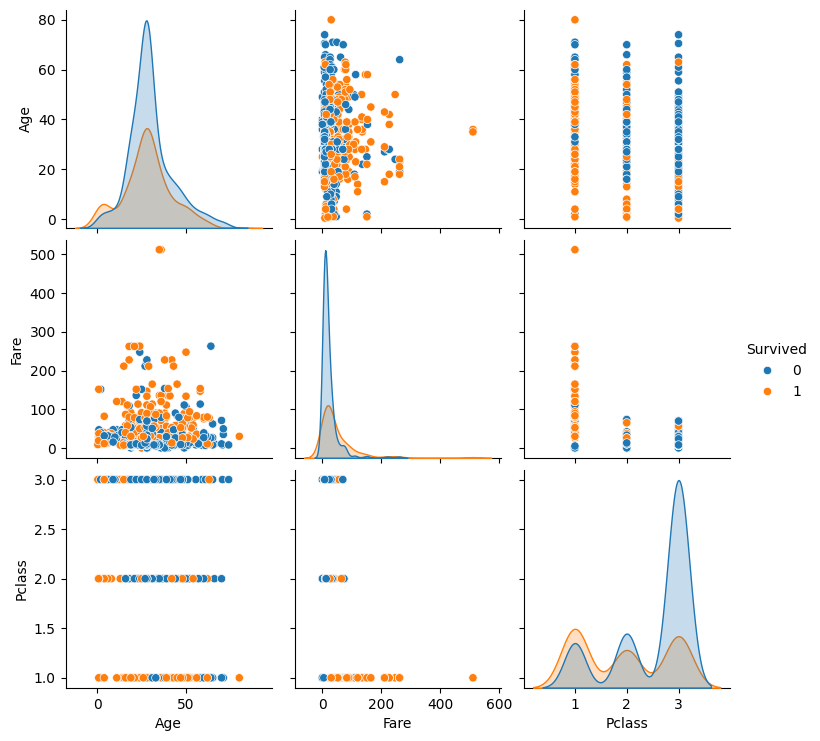

In [29]:
sns.pairplot(df[["Survived", "Age", "Fare", "Pclass"]], hue="Survived")

plt.show()

# Conclusion

The Titanic dataset was cleaned and analyzed using exploratory data analysis techniques. The analysis showed that passenger class, gender, and fare were associated with survival. Female passengers and those traveling in First Class had higher survival rates than others. Most passengers were adults between 20 and 40 years of age, and the fare distribution contained several high-value outliers. Overall, the project demonstrates how visualization and statistical analysis can reveal meaningful patterns in real-world datasets.